# Courbes périodiques : MLP dense, MLP partagé et CNN

Ce notebook accompagne l'exercice 2.5 du cours. Nous voulons reconstruire une famille de courbes périodiques à partir de l'amplitude, de la fréquence et du décalage.

L'expérience compare deux machines. La première produit toute la courbe avec des matrices pleines. La seconde applique le même MLP à chaque point de la grille : cette structure correspond exactement à un CNN unidimensionnel dont les noyaux ont une largeur égale à $1$.

## Parcours

1. [Construire les données](#donnees-periodiques)
2. [MLP dense](#mlp-dense)
3. [MLP partagé](#mlp-partage)
4. [Apprentissage et comparaison](#comparaison-machines)
5. [Partage des poids et équivariance](#equivariance)
6. [Complément : convolution périodique](#convolution-periodique)

In [1]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import flax
from flax import nnx

print(f"JAX {jax.__version__}, Flax {flax.__version__}, Optax {optax.__version__}")

JAX 0.11.1, Flax 0.12.9, Optax 0.2.8


<a id="donnees-periodiques"></a>
## 1. Construire les données

Sur la grille périodique $x_j=j/n_x$, nous considérons
$$
u_{a,k,\tau}(x)=a\sin\bigl(2\pi k(x-\tau)\bigr),
\qquad
U(a,k,\tau)=\bigl(u_{a,k,\tau}(x_j)\bigr)_j.
$$

Les décalages de l'ensemble d'apprentissage sont des multiples pairs de $1/16$ ; ceux de l'ensemble de test sont les multiples impairs. Le test porte donc sur des décalages absents des données d'apprentissage.

In [2]:
n_x = 64
k_max = 5
grille = jnp.arange(n_x) / n_x

def courbes(parametres):
    a = parametres[:, 0:1]
    k = parametres[:, 1:2]
    tau = parametres[:, 2:3]
    return a * jnp.sin(2.0 * jnp.pi * k * (grille[None, :] - tau))

def generer_parametres(cle, n_donnees, indices_tau):
    cle_a, cle_k, cle_tau = jax.random.split(cle, 3)
    a = jax.random.uniform(cle_a, (n_donnees,), minval=0.5, maxval=1.5)
    k = jax.random.randint(cle_k, (n_donnees,), minval=1, maxval=k_max + 1)
    indice_tau = jax.random.choice(cle_tau, indices_tau, shape=(n_donnees,))
    tau = indice_tau / 16.0
    return jnp.stack((a, k, tau), axis=1)

cle_apprentissage, cle_test = jax.random.split(jax.random.key(2026))
parametres_apprentissage = generer_parametres(
    cle_apprentissage, 512, jnp.arange(0, 16, 2)
)
parametres_test = generer_parametres(
    cle_test, 256, jnp.arange(1, 16, 2)
)
z_apprentissage = courbes(parametres_apprentissage)
z_test = courbes(parametres_test)

print(parametres_apprentissage.shape, z_apprentissage.shape)

(512, 3) (512, 64)


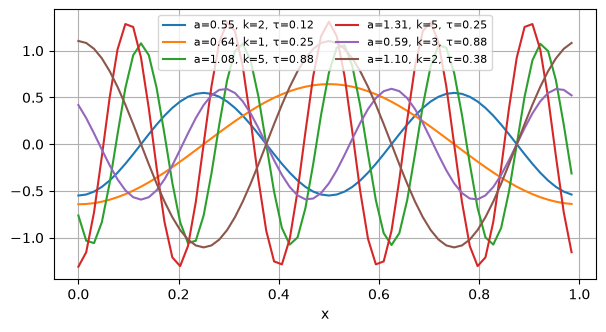

In [3]:
plt.figure(figsize=(7, 3.5))
for i in range(6):
    a, k, tau = parametres_apprentissage[i]
    plt.plot(grille, z_apprentissage[i], label=f"a={a:.2f}, k={int(k)}, τ={tau:.2f}")
plt.xlabel("x")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()

<a id="mlp-dense"></a>
## 2. MLP dense

Construire avec Flax NNX un MLP dense
$$
G_p:\mathbb R^3\longrightarrow\mathbb R^{n_x}.
$$

On utilisera deux couches cachées de largeur $64$ et la fonction d'activation `tanh`. Les matrices de la dernière couche sont pleines : chaque valeur de sortie possède donc ses propres coefficients.

In [ ]:
# À compléter.

<a id="mlp-partage"></a>
## 3. MLP partagé

Nous associons à $(a,k,\tau)$ l'entrée spatiale $X(a,k,\tau)\in\mathbb R^{n_x\times4}$ donnée par
$$
X(a,k,\tau)_{j,:}
=\bigl(a,k,\cos(2\pi(x_j-\tau)),\sin(2\pi(x_j-\tau))\bigr).
$$

Construire ensuite un MLP $g_q:\mathbb R^4\to\mathbb R$ et appliquer le **même** MLP à chaque ligne :
$$
\bigl(C_q(X)\bigr)_j=g_q(X_{j,:}).
$$

Avec NNX, une couche `Linear` agit automatiquement sur la dernière dimension du tableau : les dimensions précédentes jouent le rôle d'indices de données et de position.

In [5]:
def entree_spatiale(parametres):
    a = parametres[:, 0:1]
    k = parametres[:, 1:2]
    tau = parametres[:, 2:3]
    phase = 2.0 * jnp.pi * (grille[None, :] - tau)
    return jnp.stack(
        (
            jnp.broadcast_to(a, phase.shape),
            jnp.broadcast_to(k, phase.shape),
            jnp.cos(phase),
            jnp.sin(phase),
        ),
        axis=-1,
    )

x_partage_apprentissage = entree_spatiale(parametres_apprentissage)
x_partage_test = entree_spatiale(parametres_test)
print(x_partage_apprentissage.shape)

(512, 64, 4)


In [ ]:
# À compléter.

<a id="comparaison-machines"></a>
## 4. Apprentissage et comparaison

La construction des données et la boucle d'apprentissage sont fournies. Ajuster les deux machines avec la même erreur quadratique moyenne ('mean squared error', MSE), puis comparer leur erreur sur les décalages absents de l'ensemble d'apprentissage.

In [7]:
def cout(machine, x, z):
    return jnp.mean((machine(x) - z) ** 2)

@nnx.jit
def pas_apprentissage(machine, optimiseur, x, z):
    valeur, gradient = nnx.value_and_grad(cout)(machine, x, z)
    optimiseur.update(machine, gradient)
    return valeur

def apprendre(machine, x, z, n_iterations=1500, alpha=3.0e-3):
    optimiseur = nnx.Optimizer(machine, optax.adam(alpha), wrt=nnx.Param)
    historique = []
    for _ in range(n_iterations):
        valeur = pas_apprentissage(machine, optimiseur, x, z)
        historique.append(float(valeur))
    return historique

In [ ]:
# À compléter.

In [ ]:
# À compléter.

### Nombre de paramètres

1. Combien de paramètres possède une couche dense de $r$ entrées et $n_x$ sorties ?
2. Combien en possède une couche partagée de $c_{\rm in}$ canaux d'entrée et $c_{\rm out}$ canaux de sortie ?
3. Vérifier le nombre total de paramètres des deux machines construites ci-dessus.

In [ ]:
# À compléter.

<a id="equivariance"></a>
## 5. Partage des poids et équivariance

Pour $r\in\mathbb Z$, soit
$$
(T_rv)_j=v_{(j-r)\bmod n_x}.
$$

1. Vérifier les identités
   $$
   T_rU(a,k,\tau)=U\left(a,k,\tau+\frac r{n_x}\right),
   \qquad
   T_rX(a,k,\tau)=X\left(a,k,\tau+\frac r{n_x}\right).
   $$
2. Vérifier que $C_q(T_rX)=T_rC_q(X)$, même avant l'apprentissage.
3. Expliquer pourquoi le MLP partagé est exactement un CNN unidimensionnel de largeur de noyau $1$.

In [ ]:
# À compléter.

<a id="convolution-periodique"></a>
## 6. Complément : convolution périodique

Pour un noyau de largeur $2s+1$, la fonction suivante réalise directement une convolution périodique. La dernière dimension contient les canaux ; l'avant-dernière est l'indice spatial.

Utiliser cette fonction pour vérifier l'équivariance d'une couche de largeur $3$ ou $5$. On pourra ensuite remplacer les couches `Linear` du MLP partagé par des couches de ce type et apprendre les noyaux.

In [12]:
def convolution_periodique(x, noyau, biais):
    largeur = noyau.shape[0]
    assert largeur % 2 == 1
    s = largeur // 2
    y = jnp.broadcast_to(biais, x.shape[:-1] + (biais.size,))
    for indice, decalage in enumerate(range(-s, s + 1)):
        y = y + jnp.roll(x, decalage, axis=-2) @ noyau[indice]
    return y

In [ ]:
# À compléter.

## Bilan

Le MLP dense et le MLP partagé sont tous deux des machines capables d'approcher les courbes. La différence essentielle vient de la structure : le MLP partagé utilise les mêmes paramètres à chaque position, possède un nombre de paramètres indépendant de $n_x$ pour chaque couche et est équivariant par translation.

Un CNN de largeur $1$ n'est donc pas une nouvelle sorte de composition : c'est un MLP appliqué en chaque point avec partage des poids. Les noyaux plus larges ajoutent ensuite des interactions locales entre positions voisines.